In [1]:
from scoresbibm.src.tasks.all_conditional_tasks import TwoMoonsAllConditionalTask, SLCPAllConditionalTask, NonlinearGaussianTreeAllConditionalTask, NonlinearMarcovChainAllConditionalTask
from scoresbibm.src.tasks.sbibm_tasks import TwoMoons, SBIBMTask
from scoresbibm.src.tasks.base_task import InferenceTask, Task, AllConditionalTask

import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

In [2]:
#task = TwoMoonsAllConditionalTask()
task = SLCPAllConditionalTask()
#task = NonlinearMarcovChainAllConditionalTask()
# task = NonlinearGaussianTreeAllConditionalTask()

In [3]:
dim = jax.tree_util.tree_reduce(lambda x, y: x + y, task.var_sizes)

In [4]:
base_mask_fn = task.get_base_mask_fn()
node_id = jnp.arange(dim)

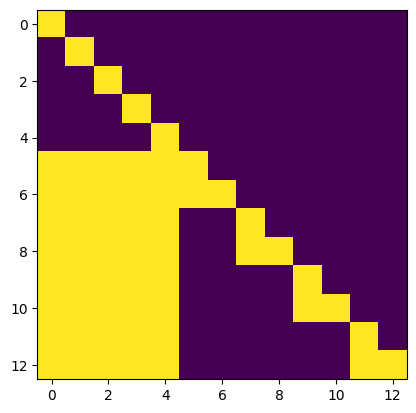

In [5]:
plt.imshow(base_mask_fn(node_id, None))

In [6]:
reference_sampler = task.get_reference_sampler()

In [7]:
# Two moons
theta, x = task.get_thetas_xs(1, rng=jax.random.PRNGKey(0))
theta_dim = theta.shape[-1]
x_dim = x.shape[-1]
print(x_dim, theta_dim)
samples = reference_sampler.sample(2000,x_o = x[0], condition_mask=jnp.array([0]*theta_dim + [1] * x_dim), rng=jax.random.PRNGKey(0))

8 5


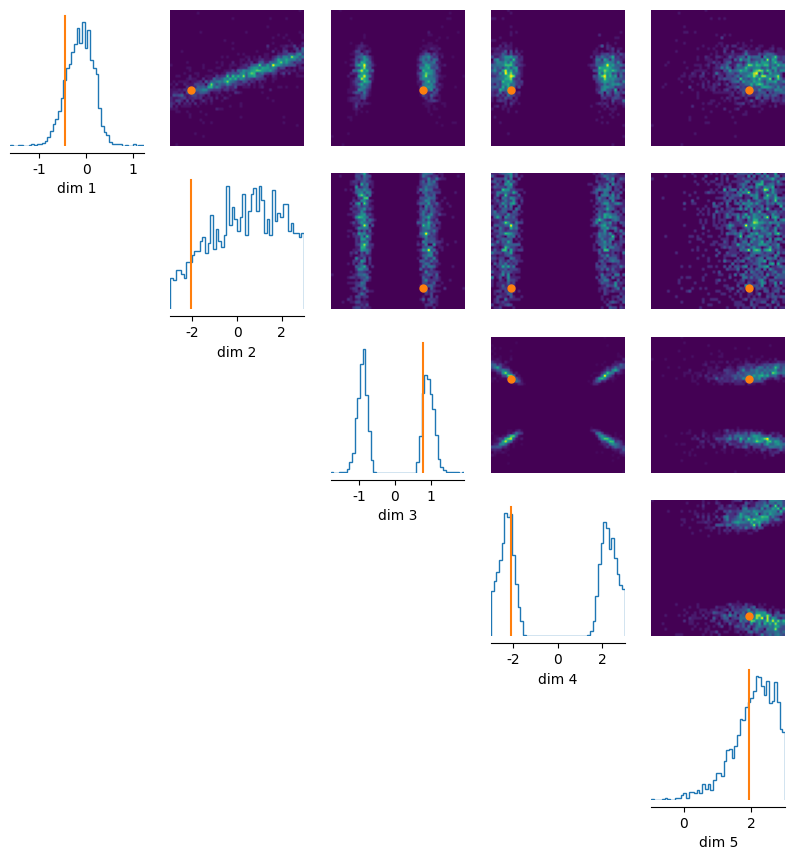

In [8]:
import matplotlib.pyplot as plt 
import seaborn as sns
from sbi.analysis import pairplot
import numpy as np

_ = pairplot(np.array(samples), points=np.array(theta[0]))

[False  True False  True False  True False False  True] [-1.872 -0.937 -1.14  -1.281  6.408  0.887] [-1.406  2.256  0.437 -9.363 -2.098  4.596 -0.367]


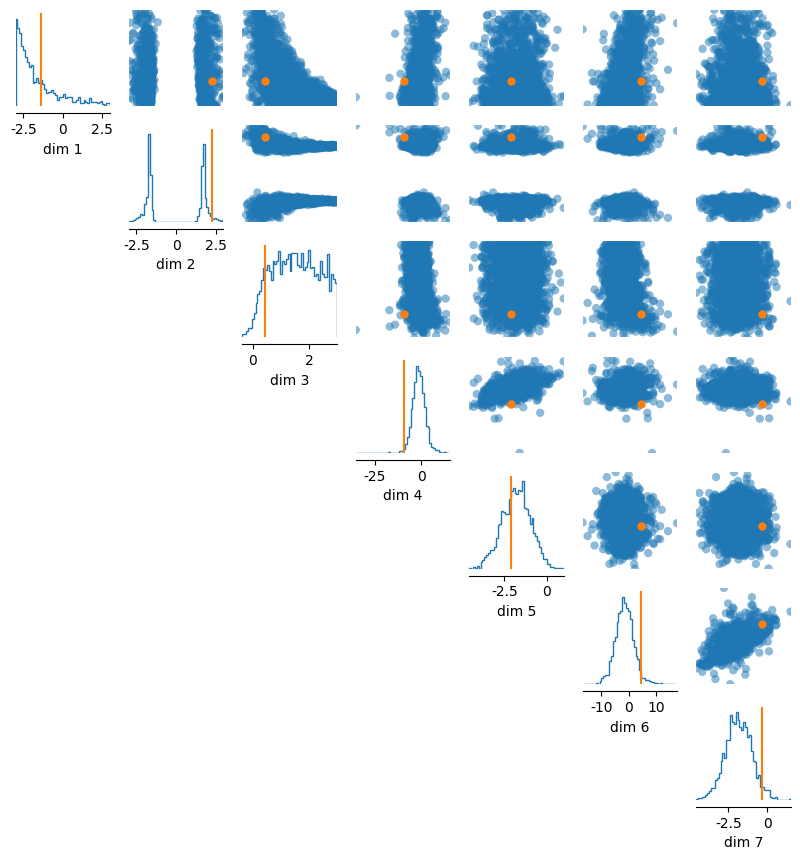

[ True  True  True  True  True  True  True  True False] [-0.957  2.516  1.035  1.936 -0.232 -0.185  2.691 -1.04   1.743 -1.597
  5.166] [-1.812 12.011]


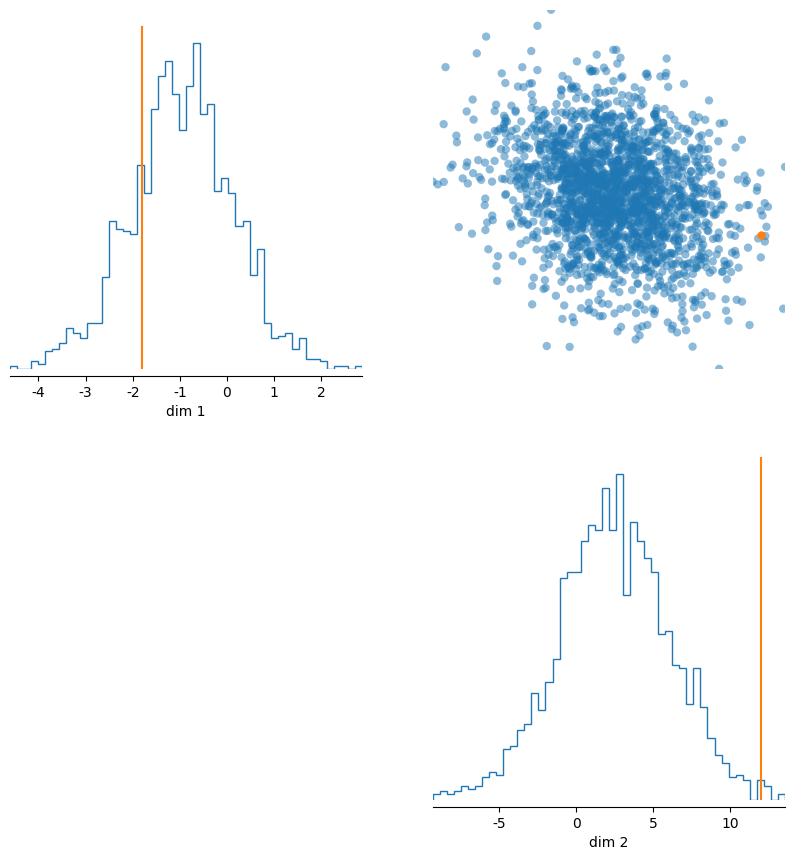

[False False False  True False False False  True False] [ 2.869 -2.198 -5.846] [ -2.022  -1.721   1.584   0.928  -2.392  -0.028  -3.419  -2.591  -4.622
 -17.957]


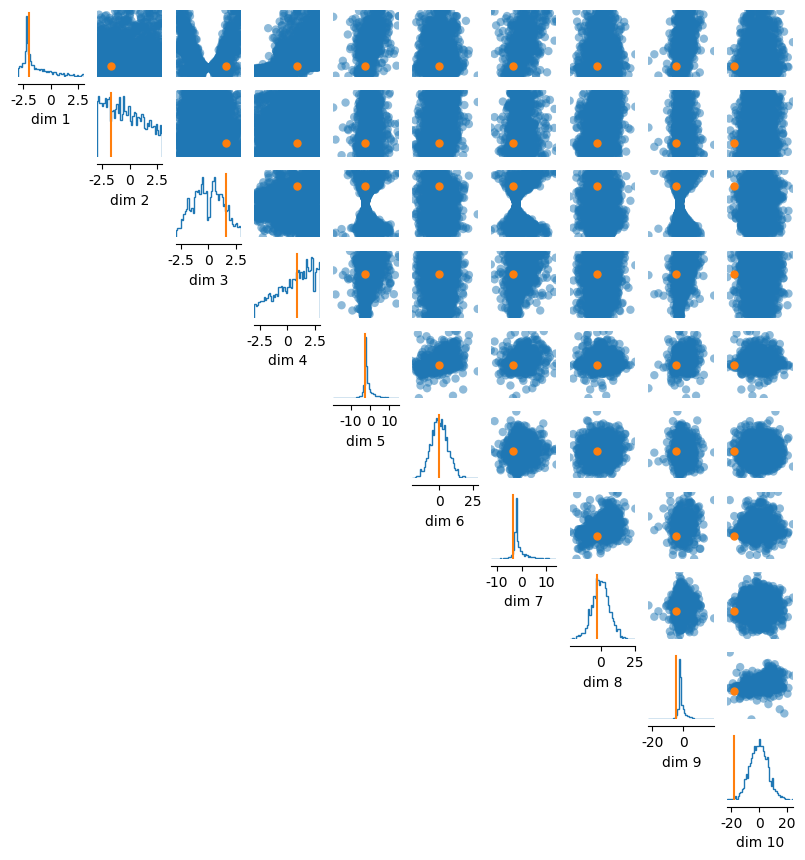

[ True  True False  True  True  True  True False False] [-0.515  2.718 -0.319 -0.401 -3.576  2.761 -4.554  2.673] [-2.904 -4.503  2.706 -3.391  2.707]


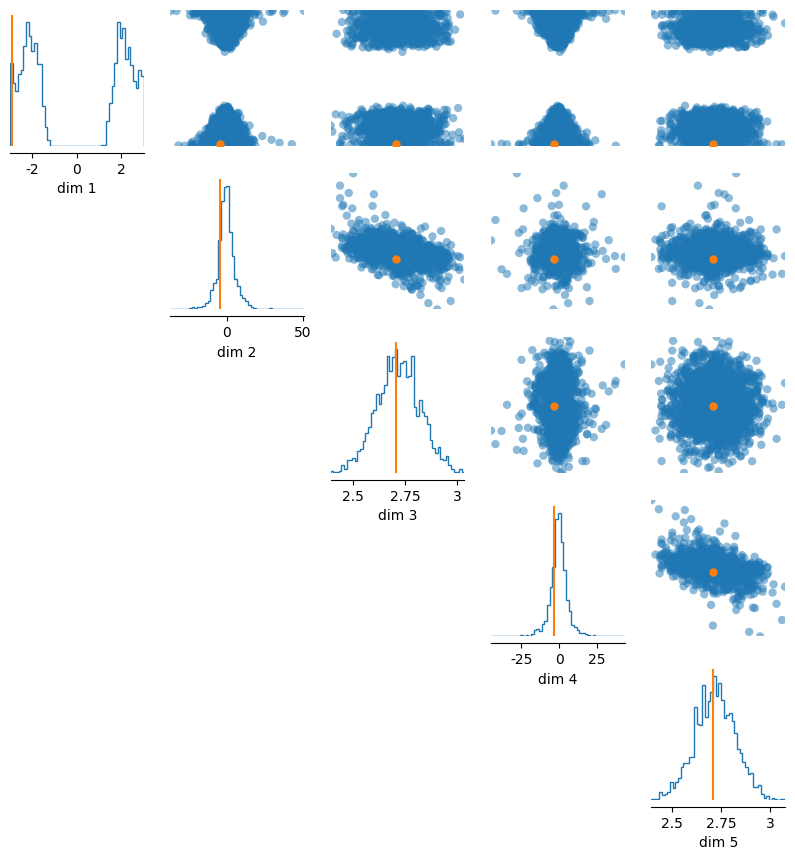

[ True False  True False  True  True  True False False] [-1.267 -0.542  1.414 -0.944  2.62  -0.863  2.689] [ 2.408 -0.552 -0.827  2.494 -1.424  2.344]


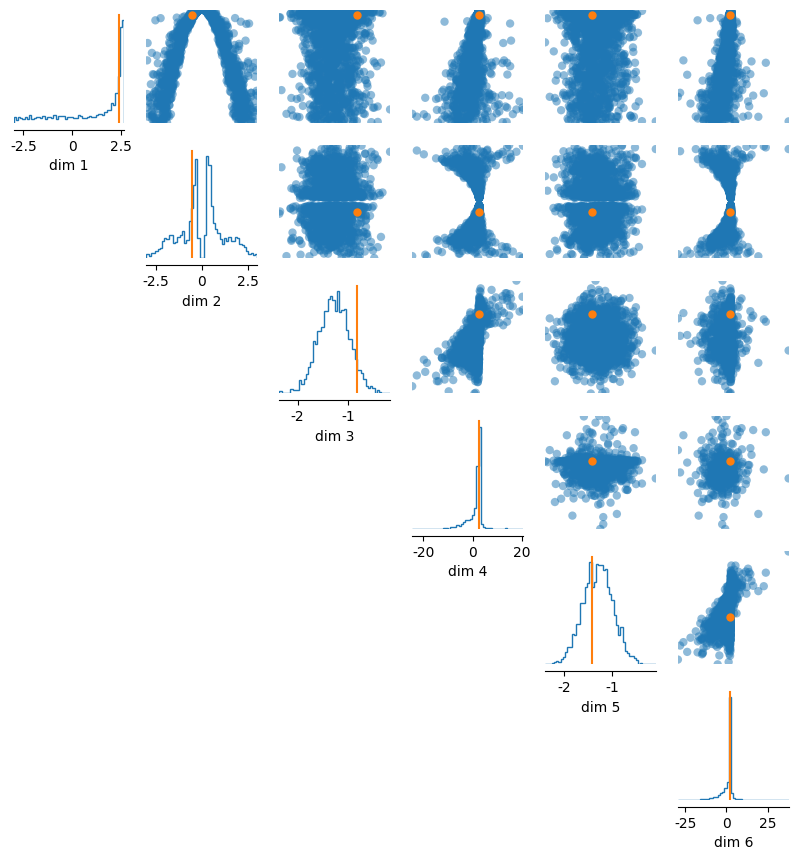

[False False  True False  True False  True False  True] [ 0.709  2.639  0.556 -9.465  0.964 -3.884] [ 1.274  0.666 -2.587  0.943 -4.09   0.731 -7.412]


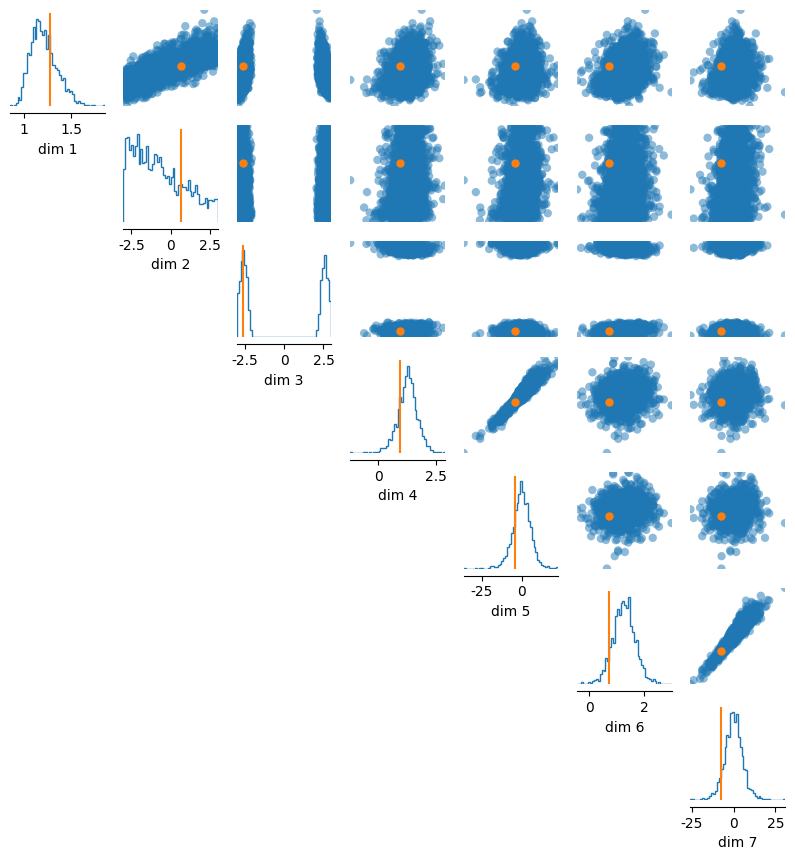

[ True False False  True  True  True False False  True] [-2.802 -0.238 -2.838 -4.052  1.688 -2.243  1.6  ] [ 1.632  1.111 -3.621  1.67  -1.667  1.577]


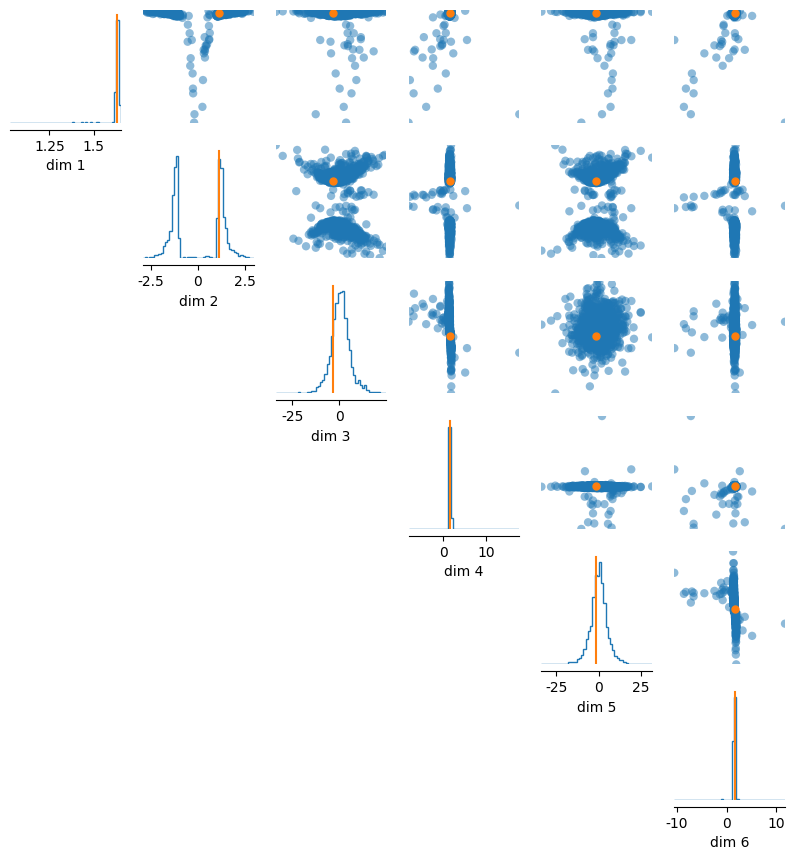

[ True False  True False  True  True False  True  True] [-0.456  2.198 -1.069 -3.531  0.757 -4.453  5.203 -4.021 -0.251] [-0.046  2.193 -7.566  5.862]


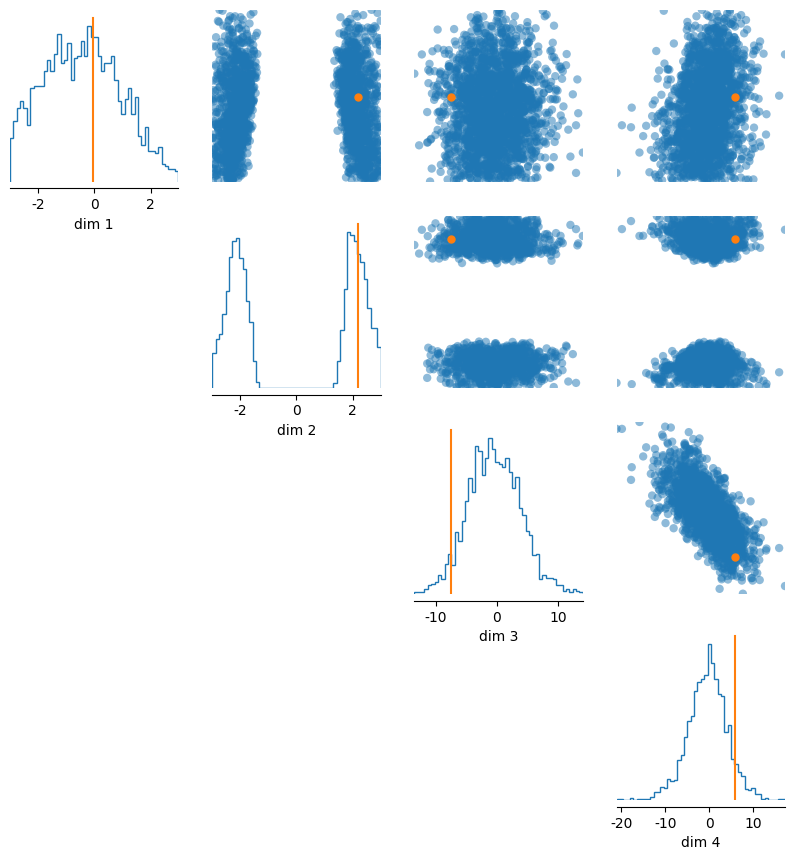

[ True  True False False False  True False False False] [-0.266  2.22   5.441 10.722] [-1.824  2.88   1.283 -3.292 -7.173 -0.67   6.538  0.56   4.025]


In [9]:
observation_stream = task.get_observation_generator()(jax.random.PRNGKey(0))
for i in range(20):
    # Two moons
    condition_mask, x_o, theta_o = next(observation_stream)
    print(condition_mask, x_o, theta_o)
    # Two moons
    samples = reference_sampler.sample(2000,x_o = x_o, condition_mask=condition_mask, rng=jax.random.PRNGKey(i))
    _ = pairplot(np.array(samples), points=np.array(theta_o), upper="scatter")
    plt.show()